In [4]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt

plt.style.use("dark_background")

In [5]:
df = yf.download('AAPL', start='2018-01-01', end='2024-01-01')
prices = df['Close']['AAPL']
prices.to_csv('../data/aapl_prices.csv')
print(prices.head())
print(prices.shape)

[*********************100%***********************]  1 of 1 completed

Date
2018-01-02    40.267067
2018-01-03    40.260059
2018-01-04    40.447075
2018-01-05    40.907574
2018-01-08    40.755634
Name: AAPL, dtype: float64
(1509,)


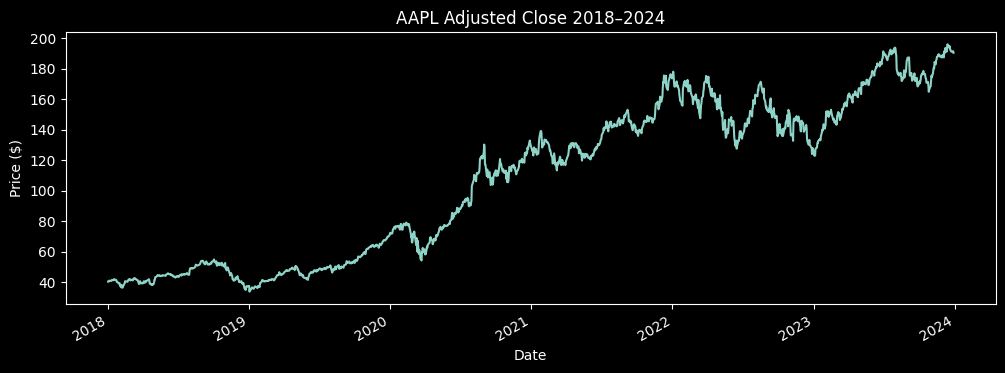

In [6]:
prices.plot(figsize=(12, 4), title='AAPL Adjusted Close 2018–2024')
plt.ylabel('Price ($)')
plt.show()

In [7]:
returns = np.log(prices / prices.shift(1)).dropna()
target = returns.shift(-1).dropna()
returns = returns[returns.index.isin(target.index)]
print(returns.shape, target.shape)

(1507,) (1507,)


In [8]:
print(f"Returns shape: {returns.shape}")
print(f"Target shape: {target.shape}")
print(f"Any NaN in returns: {returns.isna().any()}")
print(f"Any NaN in target: {target.isna().any()}")
print(f"\nFirst 5 returns:\n{returns.head()}")
print(f"\nFirst 5 targets:\n{target.head()}")

Returns shape: (1507,)
Target shape: (1507,)
Any NaN in returns: False
Any NaN in target: False

First 5 returns:
Date
2018-01-03   -0.000174
2018-01-04    0.004634
2018-01-05    0.011321
2018-01-08   -0.003721
2018-01-09   -0.000115
Name: AAPL, dtype: float64

First 5 targets:
Date
2018-01-03    0.004634
2018-01-04    0.011321
2018-01-05   -0.003721
2018-01-08   -0.000115
2018-01-09   -0.000230
Name: AAPL, dtype: float64


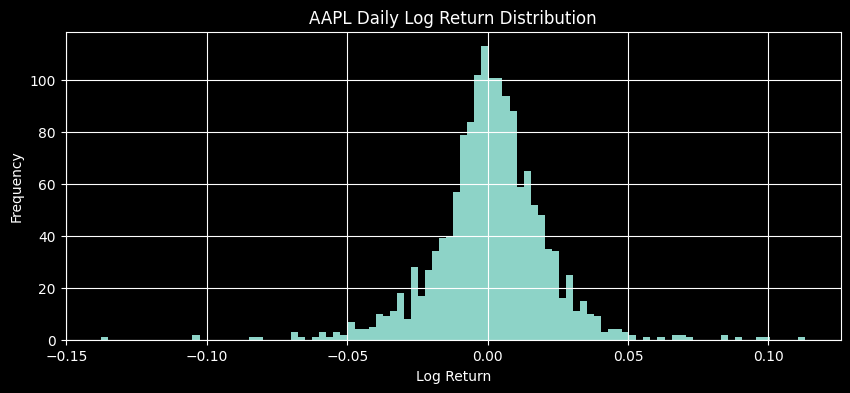

In [9]:
returns.hist(bins=100, figsize=(10, 4))
plt.title('AAPL Daily Log Return Distribution')
plt.xlabel('Log Return')
plt.ylabel('Frequency')
plt.show()

In [10]:
features = pd.DataFrame(index=prices.index)
sma5  = prices.rolling(5).mean()
sma20 = prices.rolling(20).mean()
sma50 = prices.rolling(50).mean()
ema12 = prices.ewm(span=12).mean()
ema26 = prices.ewm(span=26).mean()
price_vs_sma20 = (prices / sma20) - 1
sma_crossover  = (sma5 > sma20).astype(int)
macd           = ema12 - ema26
macd_signal    = macd.ewm(span=9).mean()
features['sma5']           = sma5
features['sma20']          = sma20
features['sma50']          = sma50
features['ema12']          = ema12
features['ema26']          = ema26
features['price_vs_sma20'] = price_vs_sma20
features['sma_crossover']  = sma_crossover
features['macd']           = macd
features['macd_signal']    = macd_signal
print(features.shape)
print(features.head(10))

(1509, 9)
                 sma5  sma20  sma50      ema12      ema26  price_vs_sma20  \
Date                                                                        
2018-01-02        NaN    NaN    NaN  40.267067  40.267067             NaN   
2018-01-03        NaN    NaN    NaN  40.263271  40.263428             NaN   
2018-01-04        NaN    NaN    NaN  40.335010  40.329411             NaN   
2018-01-05        NaN    NaN    NaN  40.515746  40.491040             NaN   
2018-01-08  40.527482    NaN    NaN  40.580923  40.552400             NaN   
2018-01-09  40.624258    NaN    NaN  40.622248  40.592168             NaN   
2018-01-10  40.720566    NaN    NaN  40.648880  40.618743             NaN   
2018-01-11  40.825757    NaN    NaN  40.716525  40.675828             NaN   
2018-01-12  40.923468    NaN    NaN  40.850975  40.782592             NaN   
2018-01-16  41.009492    NaN    NaN  40.914416  40.838224             NaN   

            sma_crossover      macd  macd_signal  
Date          

In [11]:
print(f"First 5 rows of sma50 (should be NaN):\n{sma50.head()}")
print(f"\nFirst non-NaN row of sma50: {sma50.first_valid_index()}")
print(f"\nNaN counts per feature:\n{features.isna().sum()}")

First 5 rows of sma50 (should be NaN):
Date
2018-01-02   NaN
2018-01-03   NaN
2018-01-04   NaN
2018-01-05   NaN
2018-01-08   NaN
Name: AAPL, dtype: float64

First non-NaN row of sma50: 2018-03-14 00:00:00

NaN counts per feature:
sma5               4
sma20             19
sma50             49
ema12              0
ema26              0
price_vs_sma20    19
sma_crossover      0
macd               0
macd_signal        0
dtype: int64


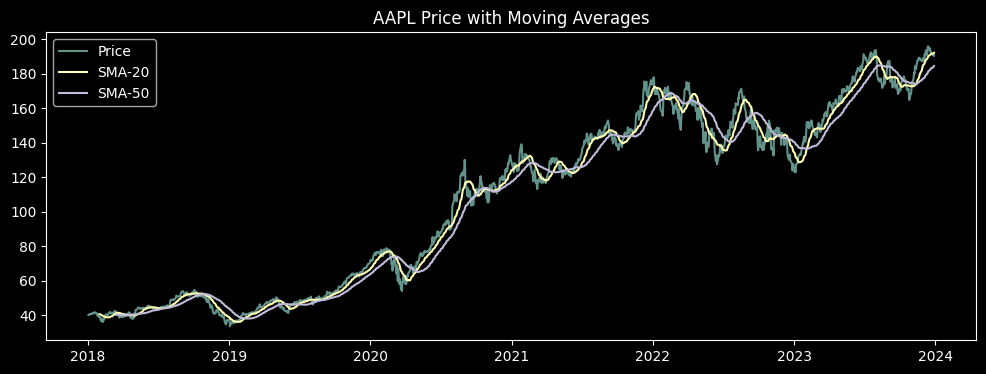

In [12]:
plt.figure(figsize=(12, 4))
plt.plot(prices, label='Price', alpha=0.7)
plt.plot(sma20, label='SMA-20')
plt.plot(sma50, label='SMA-50')
plt.title('AAPL Price with Moving Averages')
plt.legend()
plt.show()

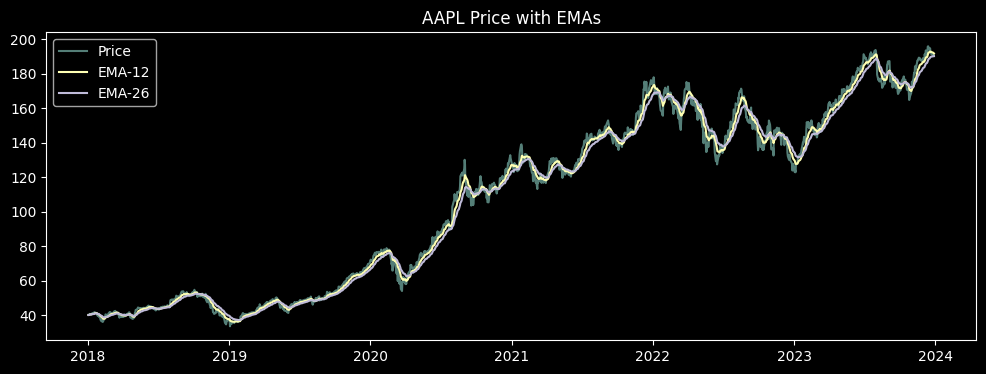

In [13]:
plt.figure(figsize=(12, 4))
plt.plot(prices, label='Price', alpha=0.6)
plt.plot(ema12, label='EMA-12')
plt.plot(ema26, label='EMA-26')
plt.title('AAPL Price with EMAs')
plt.legend()
plt.show()

In [14]:
delta = prices.diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

avg_gain = gain.ewm(alpha=1/14, adjust=False).mean()
avg_loss = loss.ewm(alpha=1/14, adjust=False).mean()

rs = avg_gain / avg_loss
rsi = 100 - (100 / (1 + rs))

features['rsi_14'] = rsi

print(f"RSI min: {rsi.min():.2f}, max: {rsi.max():.2f}")
print(rsi.head(20))
print(f"Checking if all RSI values are greater than zero: {(rsi > 0).all()}")
print(f"RSI min: {rsi.min():.2f}")
print(f"RSI max: {rsi.max():.2f}")
print(f"NaN count: {rsi.isna().sum()}")
print(rsi.head(10))

RSI min: 0.00, max: 88.23
Date
2018-01-02          NaN
2018-01-03     0.000000
2018-01-04    67.244123
2018-01-05    88.230680
2018-01-08    71.869238
2018-01-09    71.429442
2018-01-10    70.501725
2018-01-11    78.085699
2018-01-12    85.450360
2018-01-16    72.418293
2018-01-17    81.985193
2018-01-18    82.347614
2018-01-19    74.297068
2018-01-22    62.320864
2018-01-23    62.499415
2018-01-24    45.977208
2018-01-25    34.990917
2018-01-26    37.073723
2018-01-29    28.383021
2018-01-30    26.516339
Name: AAPL, dtype: float64
Checking if all RSI values are greater than zero: False
RSI min: 0.00
RSI max: 88.23
NaN count: 1
Date
2018-01-02          NaN
2018-01-03     0.000000
2018-01-04    67.244123
2018-01-05    88.230680
2018-01-08    71.869238
2018-01-09    71.429442
2018-01-10    70.501725
2018-01-11    78.085699
2018-01-12    85.450360
2018-01-16    72.418293
Name: AAPL, dtype: float64


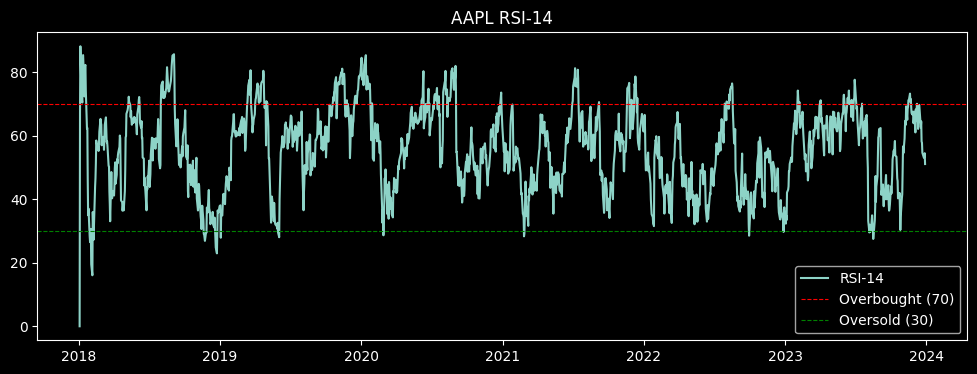

In [15]:
plt.figure(figsize=(12, 4))
plt.plot(rsi, label='RSI-14')
plt.axhline(70, color='red', linestyle='--', linewidth=0.8, label='Overbought (70)')
plt.axhline(30, color='green', linestyle='--', linewidth=0.8, label='Oversold (30)')
plt.title('AAPL RSI-14')
plt.legend()
plt.show()

In [16]:
# Volatility features — on RETURNS
vol20 = returns.rolling(20).std() * np.sqrt(252)
vol5  = returns.rolling(5).std() * np.sqrt(252)
vol_ratio = vol5 / vol20

# Bollinger Bands — on PRICES
std20      = prices.rolling(20).std()
BB_middle  = sma20
BB_upper   = BB_middle + 2 * std20
BB_lower   = BB_middle - 2 * std20
BB_percent = (prices - BB_lower) / (BB_upper - BB_lower)
bandwidth  = (BB_upper - BB_lower) / BB_middle

# Volume
volume = df['Volume']['AAPL']
volume_ratio = volume / volume.rolling(20).mean()

# Add to features
features['vol20'] = vol20
features['vol5'] = vol5
features['vol_ratio'] = vol_ratio
features['BB_middle'] = BB_middle
features['BB_upper'] = BB_upper
features['BB_lower'] = BB_lower
features['BB_percent'] = BB_percent
features['Bandwith'] =bandwidth
features['volume_ratio'] = volume_ratio


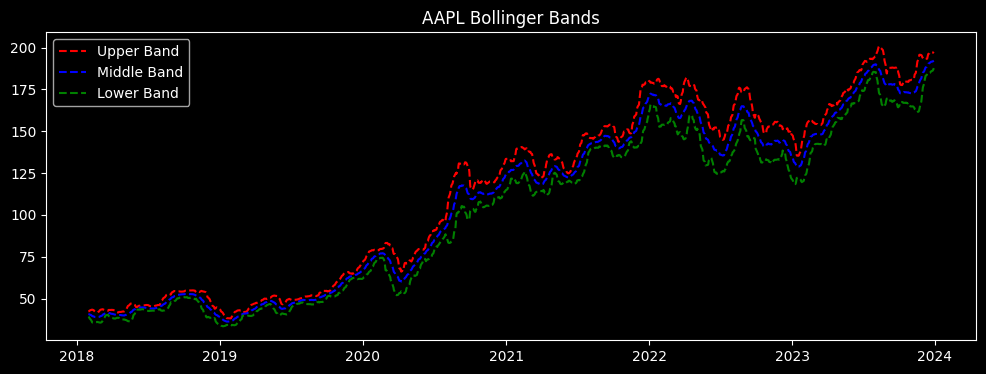

In [17]:
plt.figure(figsize=(12, 4))

plt.plot(BB_upper, label='Upper Band', linestyle='--', color='red')
plt.plot(BB_middle, label='Middle Band', linestyle='--', color='blue')
plt.plot(BB_lower, label='Lower Band', linestyle='--', color='green')
plt.title('AAPL Bollinger Bands')
plt.legend()
plt.show()

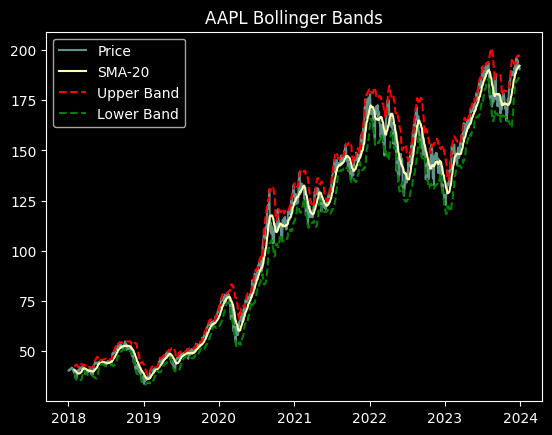

In [18]:
plt.plot(prices, label='Price', alpha=0.7)
plt.plot(sma20, label='SMA-20')
plt.plot(BB_upper, label='Upper Band', linestyle='--', color='red')

plt.plot(BB_lower, label='Lower Band', linestyle='--', color='green')
plt.title('AAPL Bollinger Bands')
plt.legend()
plt.show()

In [19]:
ret_lag1=returns.shift(1)
ret_lag2=returns.shift(2)
ret_lag3=returns.shift(3)
ret_lag4=returns.shift(4)
ret_lag5=returns.shift(5)
mom_10=returns.rolling(10).sum().shift(1)
mom_21=returns.rolling(21).sum().shift(1)
mom_63=returns.rolling(63).sum().shift(1)
features['ret_lag1'] = ret_lag1
features['ret_lag2'] = ret_lag2
features['ret_lag3'] = ret_lag3
features['ret_lag4'] = ret_lag4
features['ret_lag5'] = ret_lag5
features['mom_10'] = mom_10
features['mom_21'] = mom_21
features['mom_63'] = mom_63
df['Tomorrow_Close'] = df['Close']['AAPL'].shift(-1)
print(features.shape)

(1509, 27)


In [28]:
feature_names = features.columns.tolist()

X = features.replace([np.inf, -np.inf], np.nan)
y = target

data = X.join(y.rename('target')).dropna()
X = data[feature_names]
y = data['target']

n = int(len(data) * 0.8)
X_train, X_test = X.iloc[:n], X.iloc[n:]
y_train, y_test = y.iloc[:n], y.iloc[n:]
assert X_train.index.max() < X_test.index.min(), "Data leak!"
print(f"Train: {X_train.index.min()} → {X_train.index.max()}")
print(f"Test:  {X_test.index.min()} → {X_test.index.max()}")

Train: 2018-04-05 00:00:00 → 2022-11-02 00:00:00
Test:  2022-11-03 00:00:00 → 2023-12-28 00:00:00


In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

In [30]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
lr = LinearRegression()
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)
y_pred_lr = lr.predict(X_test_sc)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
print(rmse_lr)
r2_lr = r2_score(y_test, y_pred_lr)
print(r2_lr)

0.015036688048243466
-0.0500507429748156


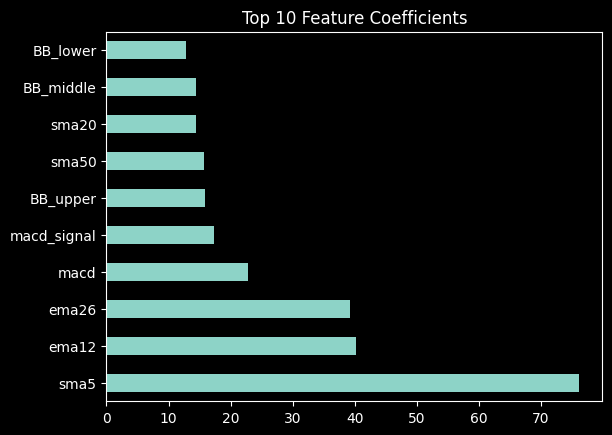

In [26]:
coeffs = pd.Series(lr.coef_, index=feature_names)
coeffs.abs().nlargest(10).plot(kind='barh')
plt.title('Top 10 Feature Coefficients')
plt.show()

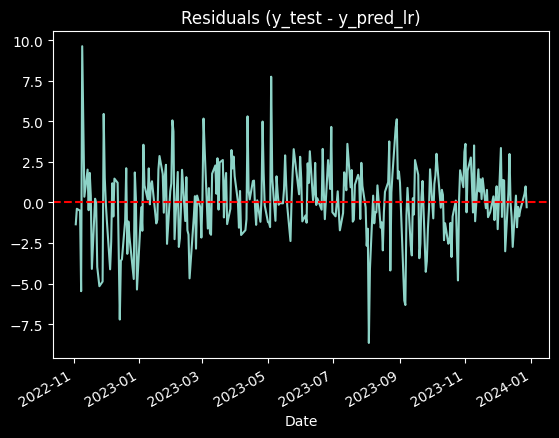

In [27]:
residuals = y_test - y_pred_lr
residuals.plot()
plt.title('Residuals (y_test - y_pred_lr)')
plt.axhline(0, color='red', linestyle='--')
plt.show()

In [31]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200, max_depth=6, min_samples_leaf=20, n_jobs=-1, random_state=42)
rf.fit(X_train_sc, y_train)
y_pred_rf = rf.predict(X_test_sc)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)
print(f"RF RMSE: {rmse_rf:.5f}")
print(f"RF R²: {r2_rf:.4f}")

RF RMSE: 0.01509
RF R²: -0.0570


In [32]:
from scipy.stats import spearmanr

dir_acc_rf = (np.sign(y_pred_rf) == np.sign(y_test)).mean()
ic_rf, pval_rf = spearmanr(y_pred_rf, y_test)

print(f"Directional Accuracy: {dir_acc_rf:.3f}")
print(f"IC (Spearman): {ic_rf:.4f}  p={pval_rf:.4f}")

Directional Accuracy: 0.474
IC (Spearman): 0.0154  p=0.7943


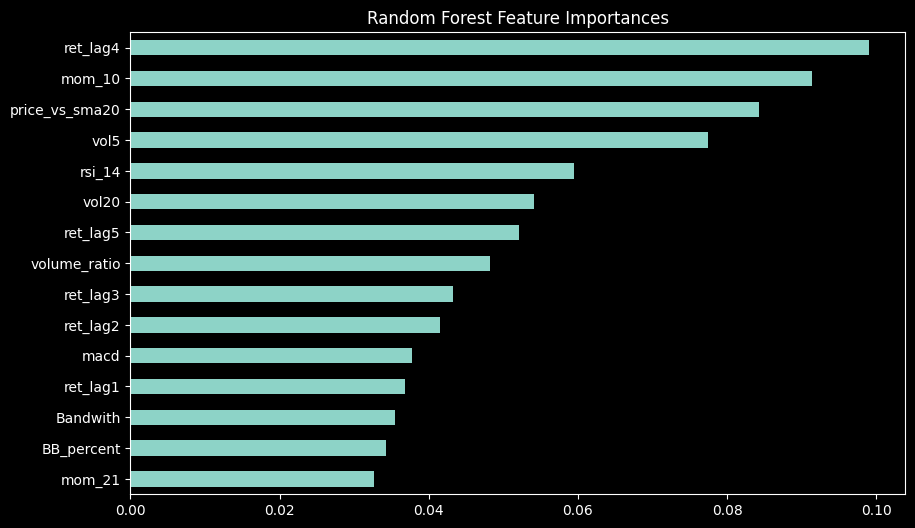

In [33]:
feat_imp = pd.Series(rf.feature_importances_, index=X.columns)
feat_imp.sort_values().tail(15).plot(kind='barh', figsize=(10, 6))
plt.title('Random Forest Feature Importances')
plt.show()